# TP 2 – Analyse en Composantes Principales (ACP)

**Module :** Analyse des données  
**Niveau :** M1 – Informatique Visuelle  
**Binôme :** Sellami Mohamed Amine et Abdesselam Meriem — G3  

##  Graphes supplémentaires
1. **Graphe des individus** sur le plan principal (F1 × F2)
2. **Graphe des variables** sur le cercle des corrélations
3. **Graphe mutuel** (biplot) des individus et des variables

## Importation des bibliothèques et préparation des données

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from numpy import linalg as LA

np.set_printoptions(precision=4, suppress=True)

X = np.array([
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9]
])

variables = ['Natation', 'Football', 'Basket', 'Tennis', 'Athletisme', 'Gym']
villes = [f'V{i+1}' for i in range(20)]

In [2]:
# reprise des fonctions 
def calcule_centre(m):
    g = np.zeros(len(m[0]))
    for i in range(len(g)):
        g[i] = np.mean(m[:, i])
    return g

def matrice_centre(m):
    vec_g = calcule_centre(m)
    c = np.zeros(m.shape)
    for i in range(len(m)):
        for j in range(len(m[i])):
            c[i][j] = m[i][j] - vec_g[j]
    return c

def ecart_type(m):
    ecarttype = np.zeros(len(m[0]))
    for i in range(len(ecarttype)):
        ecarttype[i] = np.std(m[:, i])
    return ecarttype

def matrice_centre_reduite(m):
    mcr = np.zeros(m.shape)
    etp = ecart_type(m)
    mat_c = matrice_centre(m)
    for i in range(len(m)):
        for j in range(len(m[i])):
            mcr[i][j] = mat_c[i][j] / etp[j]
    return mcr

def calcule_correlation(m):
    n = len(m)
    return (1/n) * (np.matmul(np.transpose(m), m))

# calcul ACP
Z = matrice_centre_reduite(X)
R = calcule_correlation(Z)

valp, vecp = LA.eig(R)
ordre = np.argsort(valp)[::-1]
valp = valp[ordre].real
vecp = vecp[:, ordre].real

taux = (valp / valp.sum()) * 100
composantes = Z @ vecp

# coordonnees des variables : cor(xj, Fk) = sqrt(lambda_k) * ujk
coord_var = np.zeros((len(variables), 2))
for j in range(len(variables)):
    coord_var[j, 0] = np.sqrt(valp[0]) * vecp[j, 0]
    coord_var[j, 1] = np.sqrt(valp[1]) * vecp[j, 1]

## Graphe 1 : individus sur le plan principal

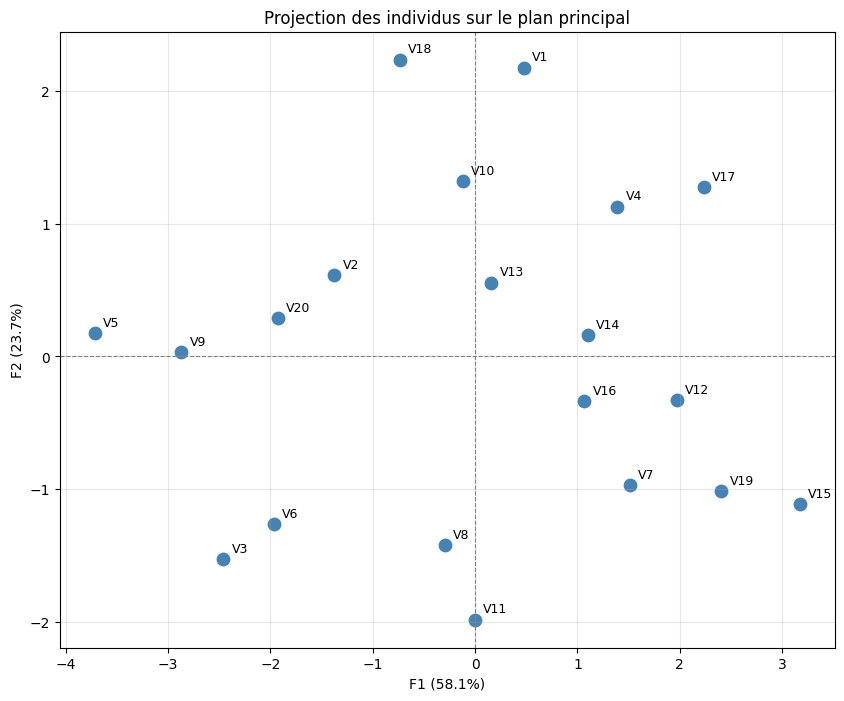

In [3]:
plt.figure(figsize=(10, 8))

plt.scatter(composantes[:, 0], composantes[:, 1], c='steelblue', s=80)

for i in range(len(villes)):
    plt.annotate(villes[i], (composantes[i, 0], composantes[i, 1]),
                 textcoords='offset points', xytext=(6, 5), fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel(f'F1 ({taux[0]:.1f}%)')
plt.ylabel(f'F2 ({taux[1]:.1f}%)')
plt.title('Projection des individus sur le plan principal')
plt.grid(alpha=0.3)
plt.show()

## Graphe 2 : Cercle des corrélations (projection des variables)

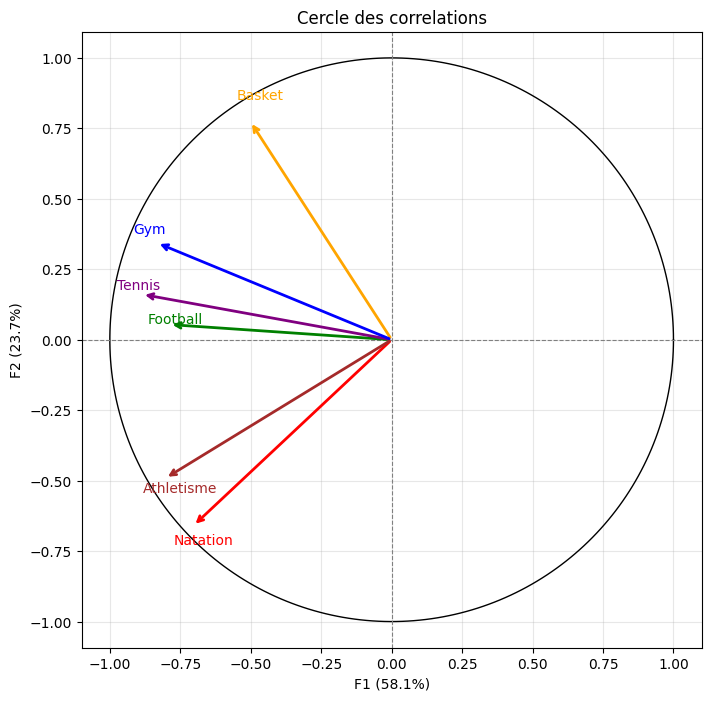

In [3]:
plt.figure(figsize=(8, 8))

# cercle unite
theta = np.linspace(0, 2 * np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

couleurs = ['red', 'green', 'orange', 'purple', 'brown', 'blue']
for j in range(len(variables)):
    plt.annotate('', xy=(coord_var[j, 0], coord_var[j, 1]), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=couleurs[j], lw=2))
    plt.text(coord_var[j, 0] * 1.1, coord_var[j, 1] * 1.1,
             variables[j], fontsize=10, color=couleurs[j])

plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)
plt.axis('equal')
plt.xlabel(f'F1 ({taux[0]:.1f}%)')
plt.ylabel(f'F2 ({taux[1]:.1f}%)')
plt.title('Cercle des correlations')
plt.grid(alpha=0.3)
plt.show()

## Graphe 3 : représentation mutuelle individus et variables (biplot)

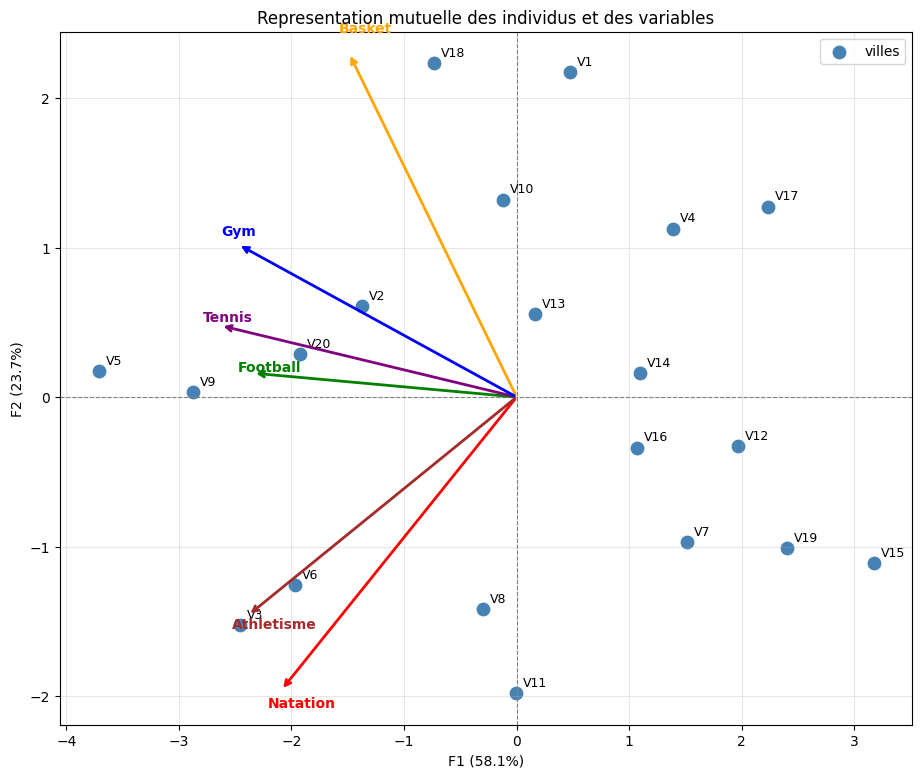

In [4]:
plt.figure(figsize=(11, 9))

# individus
plt.scatter(composantes[:, 0], composantes[:, 1], c='steelblue', s=80, label='villes')
for i in range(len(villes)):
    plt.annotate(villes[i], (composantes[i, 0], composantes[i, 1]),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)

# variables avec un facteur d'echelle
scale = abs(composantes[:, :2]).max() * 0.8
couleurs = ['red', 'green', 'orange', 'purple', 'brown', 'blue']
for j in range(len(variables)):
    fx = coord_var[j, 0] * scale
    fy = coord_var[j, 1] * scale
    plt.annotate('', xy=(fx, fy), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=couleurs[j], lw=2))
    plt.text(fx * 1.06, fy * 1.06, variables[j],
             fontsize=10, color=couleurs[j], fontweight='bold')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel(f'F1 ({taux[0]:.1f}%)')
plt.ylabel(f'F2 ({taux[1]:.1f}%)')
plt.title('Representation mutuelle des individus et des variables')
plt.legend()
plt.grid(alpha=0.3)
plt.show()